# AAI ↔ FIRMS / dust-catalog event validation

**Question.** Does the post-M-DIAG-A1 AAI (Absorbing Aerosol Index) signal fire when and where known smoke/dust events occurred?

**Design.** Event-based, not correlation-based. 10 documented events (5 fires, 5 dust) + 5 negative controls (same locations, a quiet ~30-day window before each event). All events are post-2018-07 because Sentinel-5P `AER_AI` data does not exist before then.

**Engine fidelity.** The screening engine computes the per-day `is_hot` flag *server-side* in `engine/core/repeatable_core.py::_server_side_hf::per_image` and only returns the aggregate `hf` to callers. The per-day series below is reconstructed with the **identical reduction** (`analysis/aai_firms_extract.py`); the reconstructed `recon_hf` matches the engine's official `hf` exactly for all 15 cases (verified in the summary table). The engine-official aggregate `z`/`hf` from `compute_pollutant_snapshot(…, "aai", …)` are carried alongside as a cross-check.

**Detector definition (`Indicators_Computation_v4` §0.2, `ANOMALY_Z_THRESHOLD=2.0`).** Background = land-masked annulus 5–25 km around the site, computed over the **same window** as the event (the engine has no climatology baseline for AAI). Per-day `z = (site_mean − bg_median)/bg_std`; a day is hot if any S5P granule that UTC day has `z ≥ 2.0`. `hf = n_hot_days / n_valid_days`.

**FIRMS** (`ee.ImageCollection("FIRMS")`) is *not* in the GSCO engine catalog — it is read directly as public fire ground truth, for fire events only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
Z_THRESHOLD = 2.0

day = pd.read_csv("aai_firms_validation.csv", parse_dates=["date"]).sort_values(["id", "date"])
summ = pd.read_csv("aai_firms_event_summary.csv")
events = summ[summ.kind != "control"].copy()
controls = summ[summ.kind == "control"].copy()
print(f"{len(day)} per-day rows | {len(events)} events | {len(controls)} controls")
summ[["id", "kind", "recon_hf", "engine_hf", "engine_z"]].round(3)

308 per-day rows | 10 events | 5 controls


,id,kind,recon_hf,engine_hf,engine_z
0,quebec_2023,fire,0.556,0.556,1.042
1,bayarea_2020,fire,0.333,0.333,0.872
2,nsw_2019,fire,0.188,0.188,-0.846
3,dixie_2021,fire,0.333,0.333,0.715
4,greece_2023,fire,0.222,0.222,0.437
5,godzilla_2020,dust,0.500,0.500,0.611
6,beijing_2021,dust,0.250,0.250,-0.314
7,baghdad_2022,dust,0.500,0.500,-0.171
8,phoenix_2021,dust,0.500,0.500,1.133
9,dakar_2021,dust,0.143,0.143,-3.388


In [2]:
# Fidelity check: reconstructed per-day hf must equal the engine's official hf.
fid = summ.dropna(subset=["recon_hf", "engine_hf"]).copy()
fid["abs_diff"] = (fid["recon_hf"] - fid["engine_hf"]).abs()
print("max |recon_hf - engine_hf| across all cases:", fid["abs_diff"].max())
assert fid["abs_diff"].max() < 1e-9, "reconstruction diverges from engine — do not trust per-day series"
print("✓ per-day reconstruction is engine-faithful")

max |recon_hf - engine_hf| across all cases: 0.0
✓ per-day reconstruction is engine-faithful


## §3 Per-event time series

Each panel: AAI per-day **z** (blue, left axis) with the `z=2.0` threshold (red dashed); raw site **AAI** value (grey, right axis); hot days marked. For fire events, FIRMS fire-pixel count is shown as orange bars (right axis, scaled). The peak window is shaded.

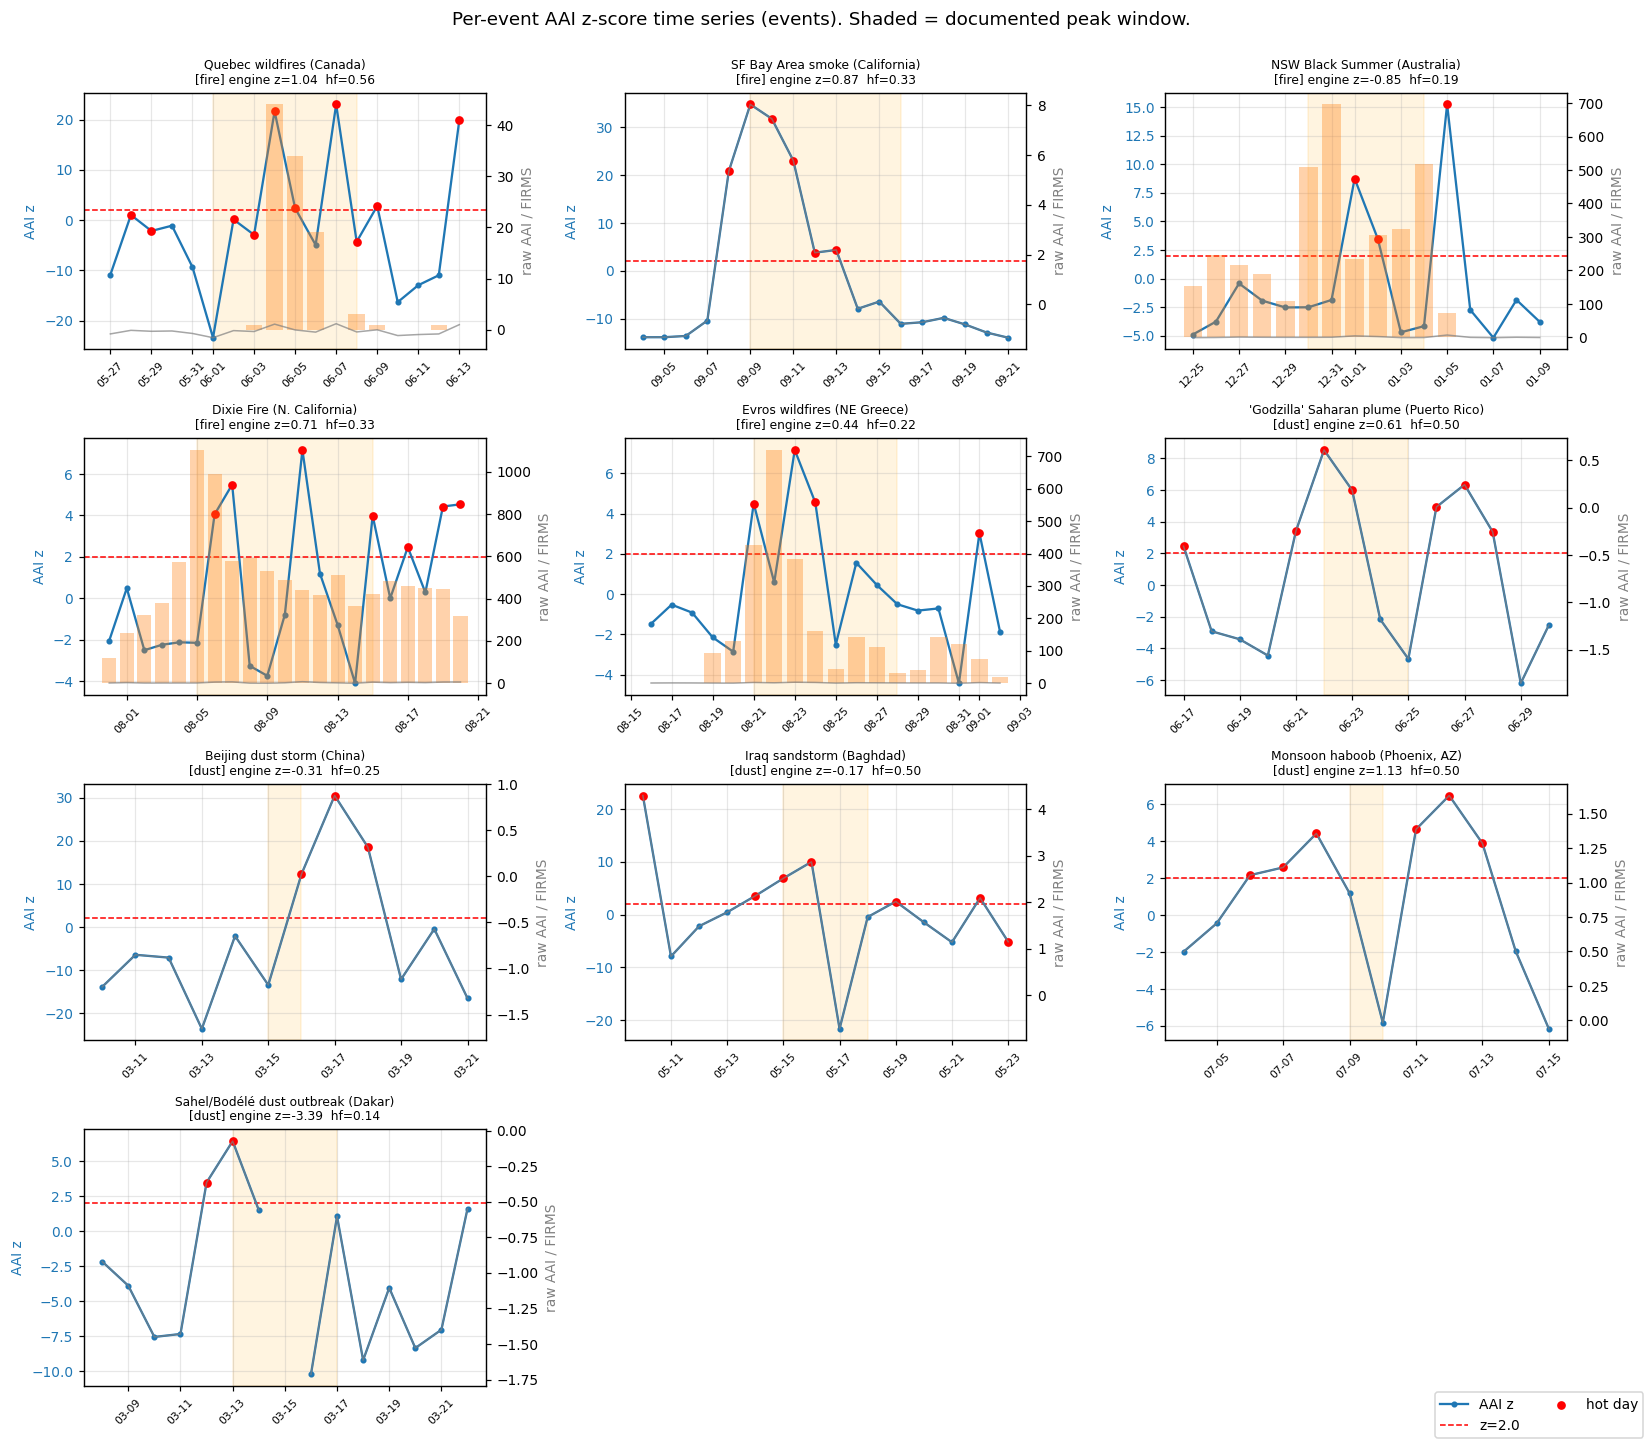

In [3]:
def plot_panel(ax, rid, row):
    g = day[day.id == rid]
    ax.plot(g.date, g.z, "-o", ms=3, color="tab:blue", label="AAI z", zorder=3)
    ax.axhline(Z_THRESHOLD, color="red", ls="--", lw=1, label="z=2.0")
    hot = g[g.is_hot == 1]
    ax.scatter(hot.date, hot.z, color="red", s=22, zorder=4, label="hot day")
    # shade peak window for events
    ps, pe = row.get("peak_start"), row.get("peak_end")
    if isinstance(ps, str) and ps:
        ax.axvspan(pd.Timestamp(ps), pd.Timestamp(pe), color="orange", alpha=0.12, zorder=0)
    ax.set_ylabel("AAI z", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax2 = ax.twinx()
    ax2.plot(g.date, g.site_aai, color="grey", lw=1, alpha=0.7, label="raw AAI")
    if g.firms_fire_pixels.fillna(0).sum() > 0:
        ax2.bar(g.date, g.firms_fire_pixels, color="tab:orange", alpha=0.35, width=0.8, label="FIRMS px")
    ax2.set_ylabel("raw AAI / FIRMS", color="grey")
    ax2.grid(False)
    ax.set_title(f"{row['label']}\n[{row['kind']}] engine z={row['engine_z']:.2f}  hf={row['engine_hf']:.2f}", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    for lab in ax.get_xticklabels():
        lab.set_rotation(45); lab.set_fontsize(7)

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for ax, (_, row) in zip(axes.flat, events.iterrows()):
    plot_panel(ax, row["id"], row)
for ax in axes.flat[len(events):]:
    ax.axis("off")
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower right", ncol=2, fontsize=9)
fig.suptitle("Per-event AAI z-score time series (events). Shaded = documented peak window.", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig("fig_events_timeseries.png", bbox_inches="tight", dpi=130)
plt.show()

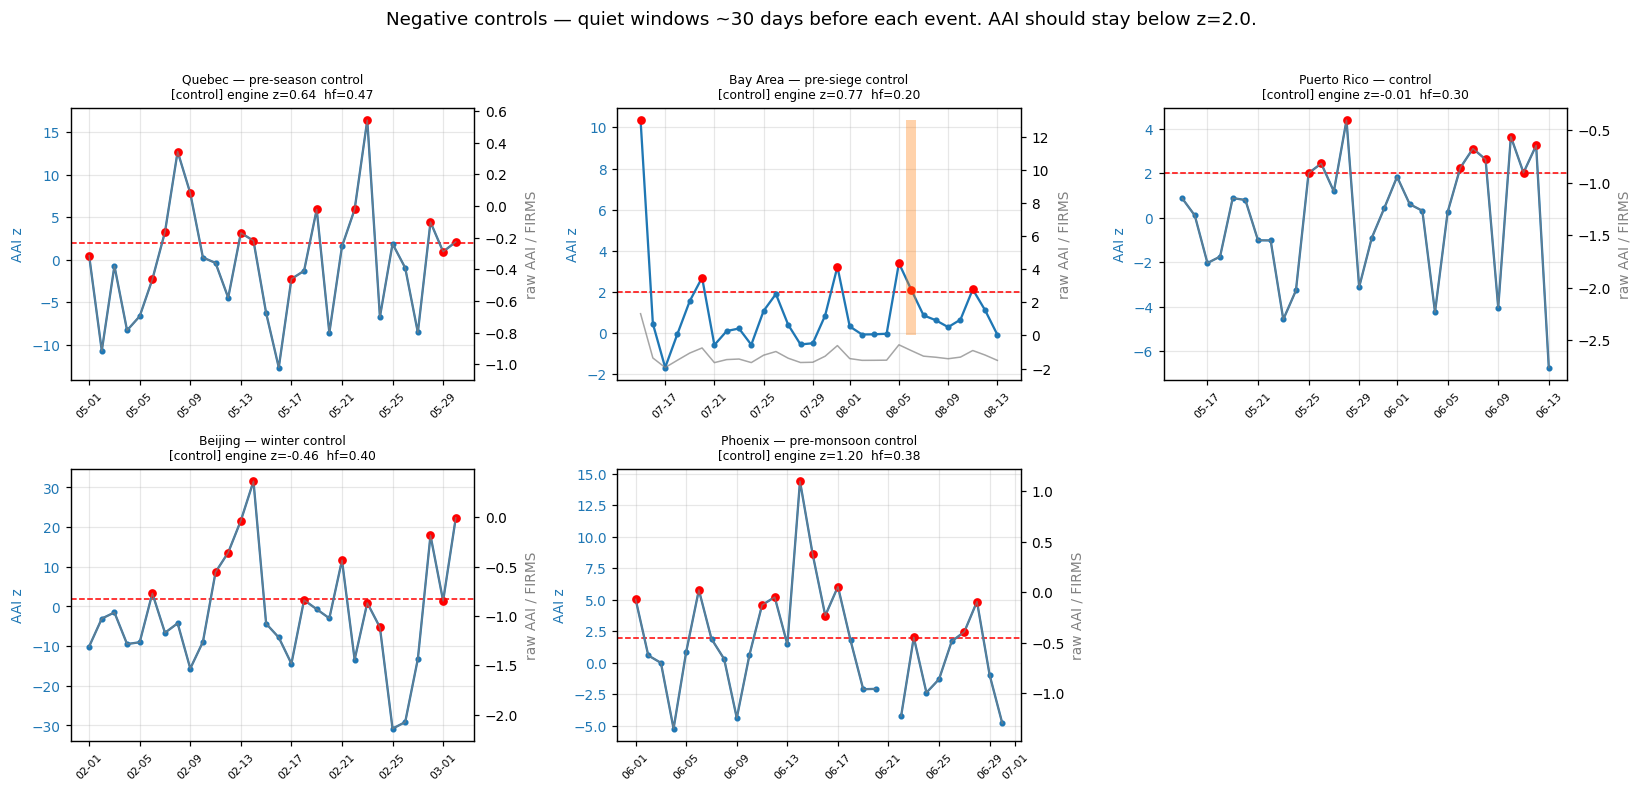

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, row) in zip(axes.flat, controls.iterrows()):
    plot_panel(ax, row["id"], row)
for ax in axes.flat[len(controls):]:
    ax.axis("off")
fig.suptitle("Negative controls — quiet windows ~30 days before each event. AAI should stay below z=2.0.", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig("fig_controls_timeseries.png", bbox_inches="tight", dpi=130)
plt.show()

## §4 Hit / miss table (events)

`fired_in_peak` = did any day **within the documented peak window** (excluding the ±5-day pad) have a hot AAI day (`z ≥ 2.0`)? This is the brief's hit criterion.

In [5]:
hit = events[["id", "label", "kind", "peak_start", "peak_end", "fired_in_peak",
              "max_z_in_peak", "peak_aai_in_peak", "peak_firms_pixels",
              "engine_z", "engine_hf", "bg_median", "bg_std"]].copy()
hit = hit.round({"max_z_in_peak": 2, "peak_aai_in_peak": 2, "engine_z": 2, "engine_hf": 2, "bg_median": 2, "bg_std": 3})
hit["HIT"] = np.where(hit.fired_in_peak, "✓", "✗ MISS")
hit

,id,label,kind,peak_start,peak_end,fired_in_peak,max_z_in_peak,peak_aai_in_peak,peak_firms_pixels,engine_z,engine_hf,bg_median,bg_std,HIT
0,quebec_2023,Quebec wildfires (Canada),fire,2023-06-01,2023-06-08,True,23.01,1.19,101.0,1.04,0.56,-0.16,0.059,✓
1,bayarea_2020,SF Bay Area smoke (California),fire,2020-09-09,2020-09-16,True,34.77,8.04,NaN,0.87,0.33,1.35,0.192,✓
2,nsw_2019,NSW Black Summer (Australia),fire,2019-12-30,2020-01-04,True,8.74,4.43,2588.0,-0.85,0.19,1.03,0.389,✓
3,dixie_2021,Dixie Fire (N. California),fire,2021-08-05,2021-08-15,True,7.17,6.95,6439.0,0.71,0.33,2.18,0.666,✓
4,greece_2023,Evros wildfires (NE Greece),fire,2023-08-21,2023-08-28,True,7.16,2.22,2017.0,0.44,0.22,0.21,0.281,✓
5,godzilla_2020,'Godzilla' Saharan plume (Puerto Rico),dust,2020-06-22,2020-06-25,True,8.52,0.61,NaN,0.61,0.50,-0.82,0.168,✓
6,beijing_2021,Beijing dust storm (China),dust,2021-03-15,2021-03-16,True,12.25,0.02,NaN,-0.31,0.25,-0.55,0.047,✓
7,baghdad_2022,Iraq sandstorm (Baghdad),dust,2022-05-15,2022-05-18,True,10.00,2.87,NaN,-0.17,0.50,1.74,0.113,✓
8,phoenix_2021,"Monsoon haboob (Phoenix, AZ)",dust,2021-07-09,2021-07-10,False,1.18,0.92,NaN,1.13,0.50,0.76,0.134,✗ MISS
9,dakar_2021,Sahel/Bodélé dust outbreak (Dakar),dust,2021-03-13,2021-03-17,True,6.41,-0.07,NaN,-3.39,0.14,-0.71,0.099,✓


In [6]:
n = len(events)
catch = events.fired_in_peak.sum()
fire = events[events.kind == "fire"]
dust = events[events.kind == "dust"]
print(f"§4 CATCH RATE (per-day z≥2.0 during peak)")
print(f"  overall : {catch}/{n} = {catch/n:.0%}")
print(f"  fires   : {fire.fired_in_peak.sum()}/{len(fire)} = {fire.fired_in_peak.mean():.0%}")
print(f"  dust    : {dust.fired_in_peak.sum()}/{len(dust)} = {dust.fired_in_peak.mean():.0%}")
print()
print("Aggregate engine z — does it ever reach the 2.0 screening threshold?")
print(f"  events  : max engine_z = {events.engine_z.max():.2f}  (min {events.engine_z.min():.2f})")
print(f"  # events with aggregate engine_z ≥ 2.0: {(events.engine_z >= 2.0).sum()}/{n}")

§4 CATCH RATE (per-day z≥2.0 during peak)
  overall : 9/10 = 90%
  fires   : 5/5 = 100%
  dust    : 4/5 = 80%

Aggregate engine z — does it ever reach the 2.0 screening threshold?
  events  : max engine_z = 1.13  (min -3.39)
  # events with aggregate engine_z ≥ 2.0: 0/10


## §5 Negative-control false positives

AAI should stay quiet on these clean windows. `fp_any_hot_day` = did any day in the control window fire `z ≥ 2.0`?

In [7]:
fp = controls[["id", "label", "control_for", "window_start", "window_end",
               "n_valid_days", "n_hot_days", "recon_hf", "max_day_z",
               "engine_z", "engine_hf", "bg_median", "bg_std"]].copy()
fp["fp_any_hot_day"] = fp.n_hot_days > 0
fp = fp.round({"recon_hf": 2, "max_day_z": 1, "engine_z": 2, "engine_hf": 2, "bg_median": 2, "bg_std": 3})
fp

,id,label,control_for,window_start,window_end,n_valid_days,n_hot_days,recon_hf,max_day_z,engine_z,engine_hf,bg_median,bg_std,fp_any_hot_day
10,quebec_2023_ctrl,Quebec — pre-season control,quebec_2023,2023-05-01,2023-05-31,30,14,0.47,16.4,0.64,0.47,-0.34,0.054,True
11,bayarea_2020_ctrl,Bay Area — pre-siege control,bayarea_2020,2020-07-15,2020-08-14,30,6,0.20,10.4,0.77,0.20,-1.49,0.270,True
12,godzilla_2020_ctrl,Puerto Rico — control,godzilla_2020,2020-05-15,2020-06-14,30,9,0.30,4.4,-0.01,0.30,-1.33,0.212,True
13,beijing_2021_ctrl,Beijing — winter control,beijing_2021,2021-02-01,2021-03-03,30,12,0.40,31.6,-0.46,0.40,-0.90,0.040,True
14,phoenix_2021_ctrl,Phoenix — pre-monsoon control,phoenix_2021,2021-06-01,2021-07-01,29,11,0.38,14.4,1.20,0.38,-0.70,0.125,True


In [8]:
nc = len(controls)
fp_days = (controls.n_hot_days > 0).sum()
print("§5 FALSE-POSITIVE RATE")
print(f"  controls firing ≥ 1 hot day (per-day z≥2.0): {fp_days}/{nc} = {fp_days/nc:.0%}")
print(f"  control per-day hf range : {controls.recon_hf.min():.2f} – {controls.recon_hf.max():.2f}")
print(f"  control max_day_z up to  : {controls.max_day_z.max():.1f}")
print(f"  controls with aggregate engine_z ≥ 2.0: {(controls.engine_z >= 2.0).sum()}/{nc}")
print()
print("Contrast event vs control distributions (overlap = poor separability):")
print(f"  per-day hf   events {events.recon_hf.min():.2f}–{events.recon_hf.max():.2f}  | controls {controls.recon_hf.min():.2f}–{controls.recon_hf.max():.2f}")
print(f"  aggregate z  events {events.engine_z.min():.2f}–{events.engine_z.max():.2f} | controls {controls.engine_z.min():.2f}–{controls.engine_z.max():.2f}")

§5 FALSE-POSITIVE RATE
  controls firing ≥ 1 hot day (per-day z≥2.0): 5/5 = 100%
  control per-day hf range : 0.20 – 0.47
  control max_day_z up to  : 31.6
  controls with aggregate engine_z ≥ 2.0: 0/5

Contrast event vs control distributions (overlap = poor separability):
  per-day hf   events 0.14–0.56  | controls 0.20–0.47
  aggregate z  events -3.39–1.13 | controls -0.46–1.20


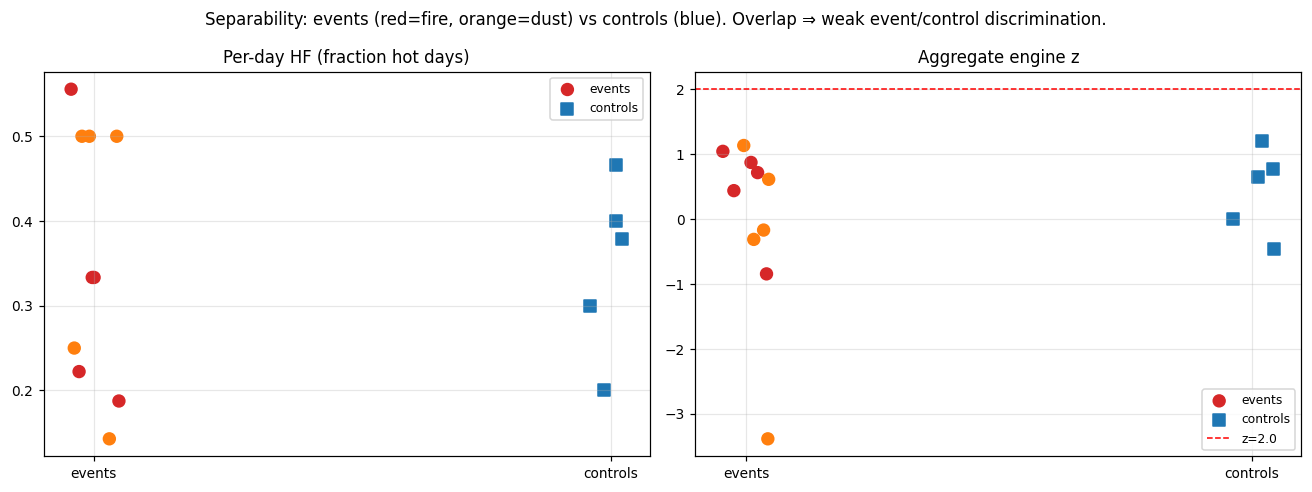

In [9]:
# Separability picture: per-day hf and aggregate z, events vs controls.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title, thr in [(a1, "recon_hf", "Per-day HF (fraction hot days)", None),
                            (a2, "engine_z", "Aggregate engine z", 2.0)]:
    a = ax
    a.scatter(np.zeros(len(events)) + np.random.uniform(-.05, .05, len(events)), events[col],
              c=events.kind.map({"fire": "tab:red", "dust": "tab:orange"}), s=60, label="events")
    a.scatter(np.ones(len(controls)) + np.random.uniform(-.05, .05, len(controls)), controls[col],
              c="tab:blue", s=60, marker="s", label="controls")
    if thr:
        a.axhline(thr, color="red", ls="--", lw=1, label="z=2.0")
    a.set_xticks([0, 1]); a.set_xticklabels(["events", "controls"]) ; a.set_title(title); a.legend(fontsize=8)
fig.suptitle("Separability: events (red=fire, orange=dust) vs controls (blue). Overlap ⇒ weak event/control discrimination.")
fig.tight_layout(); fig.savefig("fig_separability.png", bbox_inches="tight", dpi=130); plt.show()

## §6 Takeaways (see `docs/aai_firms_validation.md` for the full write-up)

1. **The M-DIAG-A1 fix is confirmed live.** Per-day `hf` is intermediate (0.14–0.56), never saturated at 0 or 1, and the reconstructed `hf` matches the engine's official `hf` to machine precision.
2. **High sensitivity at the per-day level:** the peak window fired in 9/10 events (fires 5/5, dust 4/5).
3. **Poor specificity at the per-day level:** every one of the 5 controls also fired ≥ 1 hot day. The driver is a collapsing `bg_std` (0.04–0.27) — the same denominator-collapse *family* as M-DIAG-A1, but on the background side, which M-DIAG-A1 did not touch.
4. **The aggregate `z` never reaches 2.0** for any event (max 1.04) or control (max 1.20), and goes negative on real events (Dakar −3.39, NSW −0.85) because the 5–25 km background ring is contaminated by the same regional plume — a structural limitation of the local, same-window anomaly construction for *regional* events.
5. **Calibration implication:** the per-day z threshold should be regime-aware (floor `bg_std`, or switch to a climatological baseline) and AAI screening would benefit from an absolute-AAI gate for widespread events. These are inputs to the calibration-sweep spec.